In [6]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [7]:
PROJECT_PATH = Path("..")
DATA_PATH = PROJECT_PATH / "data" / "raw"

print(DATA_PATH.resolve())

C:\Users\Sana perween\Documents\Projects\E-commerce Sales & Customer Analytics\data\raw


In [8]:
list(DATA_PATH.glob("*.csv"))

[WindowsPath('../data/raw/olist_customers_dataset.csv'),
 WindowsPath('../data/raw/olist_geolocation_dataset.csv'),
 WindowsPath('../data/raw/olist_orders_dataset.csv'),
 WindowsPath('../data/raw/olist_order_items_dataset.csv'),
 WindowsPath('../data/raw/olist_order_payments_dataset.csv'),
 WindowsPath('../data/raw/olist_order_reviews_dataset.csv'),
 WindowsPath('../data/raw/olist_products_dataset.csv'),
 WindowsPath('../data/raw/olist_sellers_dataset.csv'),
 WindowsPath('../data/raw/product_category_name_translation.csv')]

In [9]:
customers = pd.read_csv(DATA_PATH / "olist_customers_dataset.csv")
orders = pd.read_csv(DATA_PATH / "olist_orders_dataset.csv")
order_items = pd.read_csv(DATA_PATH / "olist_order_items_dataset.csv")
payments = pd.read_csv(DATA_PATH / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(DATA_PATH / "olist_order_reviews_dataset.csv")
products = pd.read_csv(DATA_PATH / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_PATH / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(
    DATA_PATH / "product_category_name_translation.csv"
)

In [10]:
tables = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

## Basic Data Audit

In [12]:
for name, df in tables.items():
    print(f"{name:25} {df.shape[0]:>8,} rows × {df.shape[1]} columns")

customers                   99,441 rows × 5 columns
orders                      99,441 rows × 8 columns
order_items                112,650 rows × 7 columns
payments                   103,886 rows × 5 columns
reviews                     99,224 rows × 7 columns
products                    32,951 rows × 9 columns
sellers                      3,095 rows × 4 columns
category_translation            71 rows × 2 columns


In [14]:
for name, df in tables.items():
    print("\n" + "-" * 60)
    print(name.upper())
    print("-" * 60)
    display(df.head(3))


------------------------------------------------------------
CUSTOMERS
------------------------------------------------------------


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



------------------------------------------------------------
ORDERS
------------------------------------------------------------


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



------------------------------------------------------------
ORDER_ITEMS
------------------------------------------------------------


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



------------------------------------------------------------
SELLERS
------------------------------------------------------------


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



------------------------------------------------------------
CATEGORY_TRANSLATION
------------------------------------------------------------


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [15]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


CUSTOMERS
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

ORDER_ITEMS
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

PAYMENTS
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

REVIEWS
review_id            

## Data Quality Audit

In [16]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(df.columns.tolist())


CUSTOMERS
--------------------------------------------------
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

ORDERS
--------------------------------------------------
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS
--------------------------------------------------
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

PAYMENTS
--------------------------------------------------
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS
--------------------------------------------------
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

PRODUCTS
--------------------------------------------------


In [17]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    display(df.head(3))


CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



ORDER_ITEMS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



CATEGORY_TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [19]:
missing_summary = []

for name, df in tables.items():
    for column in df.columns:
        missing = df[column].isna().sum()
        missing_pct = (missing / len(df)) * 100
        
        missing_summary.append({
            "table": name,
            "column": column,
            "missing_count": missing,
            "missing_percentage": round(missing_pct, 2)
        })

missing_df = pd.DataFrame(missing_summary)

missing_df = missing_df[
    missing_df["missing_count"] > 0
].sort_values(
    ["table", "missing_count"],
    ascending=[True, False]
)

missing_df

,table,column,missing_count,missing_percentage
11,orders,order_delivered_customer_date,2965,2.98
10,orders,order_delivered_carrier_date,1783,1.79
9,orders,order_approved_at,160,0.16
33,products,product_category_name,610,1.85
34,products,product_name_lenght,610,1.85
35,products,product_description_lenght,610,1.85
36,products,product_photos_qty,610,1.85
37,products,product_weight_g,2,0.01
38,products,product_length_cm,2,0.01
39,products,product_height_cm,2,0.01


In [20]:
# Duplicate audit
for name, df in tables.items():
    print(
        f"{name:25} "
        f"duplicate rows: {df.duplicated().sum():,}"
    )

customers                 duplicate rows: 0
orders                    duplicate rows: 0
order_items               duplicate rows: 0
payments                  duplicate rows: 0
reviews                   duplicate rows: 0
products                  duplicate rows: 0
sellers                   duplicate rows: 0
category_translation      duplicate rows: 0


In [21]:
print("Duplicate order_id:", orders["order_id"].duplicated().sum())
print("Duplicate customer_id:", customers["customer_id"].duplicated().sum())
print("Duplicate customer_unique_id:", customers["customer_unique_id"].duplicated().sum())
print("Duplicate product_id:", products["product_id"].duplicated().sum())
print("Duplicate seller_id:", sellers["seller_id"].duplicated().sum())

Duplicate order_id: 0
Duplicate customer_id: 0
Duplicate customer_unique_id: 3345
Duplicate product_id: 0
Duplicate seller_id: 0


In [22]:
# Check the order statuses
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [23]:
orders["order_status"].value_counts(normalize=True).mul(100).round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

In [24]:
# Inspecting the date columns
orders[[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Data Quality Decisions

- 160 rows are missing from order_approved_at, 1783 rows are missing from order_delivered_carrier_date, 2965 rows are missing from order_delivered_customer_date. These rows should not be removed as a missing delivery date can mean the order wasn't delivered yet or had another status.
- We have 610 missing values in several product columns. For our analysis, product_category_name is important. We'll eventually translate categories using product_category_name_translation.csv. For the remaining product attributes, we don't need to delete products. We'll preserve them and handle missing values only when they're relevant to a particular analysis.
- 88.34% and 58.70% values are missing from review_comment_title and review_comment_message. This looks alarming but a missing written comment doesn't mean the review itself is invalid.

- We found no duplicates in customer id (customer_id: 0) but found 3345 duplicates in customer unique id (customer_unique_id: 3345). This is confusing yet interesting. This happens because both are representing different properties. customer_id identifies the customer record associated with an order. customer_unique_id allows us to identify the same underlying customer across multiple purchases.
- For revenue analysis we wont consider cancelled orders. We'll primarily use orders that were actually delivered.

In [27]:
# analyzing repeat customers 
total_customer_records = customers["customer_id"].nunique()

unique_customers = customers["customer_unique_id"].nunique()

repeat_customer_records = (
    customers["customer_unique_id"]
    .value_counts()
)

repeat_customers = (repeat_customer_records > 1).sum()

print("Customer records:", total_customer_records)
print("Unique customers:", unique_customers)
print("Repeat customers:", repeat_customers)

Customer records: 99441
Unique customers: 96096
Repeat customers: 2997


In [28]:
repeat_customer_rate = ( repeat_customers / unique_customers) * 100
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

Repeat customer rate: 3.12%


In [30]:
# Convert date columns
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [31]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [32]:
# date range 
print("First order:", orders["order_purchase_timestamp"].min())
print("Last order:", orders["order_purchase_timestamp"].max())

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


In [34]:
print(orders["order_purchase_timestamp"].dt.to_period("M").nunique(), "months of data")

25 months of data


In [37]:
orders["order_purchase_timestamp"].dt.to_period('M')

0        2017-10
1        2018-07
2        2018-08
3        2017-11
4        2018-02
          ...   
99436    2017-03
99437    2018-02
99438    2017-08
99439    2018-01
99440    2018-03
Name: order_purchase_timestamp, Length: 99441, dtype: period[M]

In [46]:
# Check for impossible delivery dates
delivered_orders = orders[orders["order_status"] == "delivered"].copy()

In [49]:
invalid_delivery_dates = delivered_orders[
    delivered_orders["order_delivered_customer_date"] < delivered_orders["order_purchase_timestamp"] ]

print("Invalid delivery dates:", len(invalid_delivery_dates))

Invalid delivery dates: 0


In [50]:
# Check for impossible estimated delivery dates
invalid_estimated_dates = delivered_orders[
    delivered_orders["order_estimated_delivery_date"] < delivered_orders["order_purchase_timestamp"]
    ]

print("Invalid estimated delivery dates:", len(invalid_estimated_dates))

Invalid estimated delivery dates: 0


In [51]:
# Calculate Delivery time
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

In [54]:
delivered_orders["delivery_days"].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

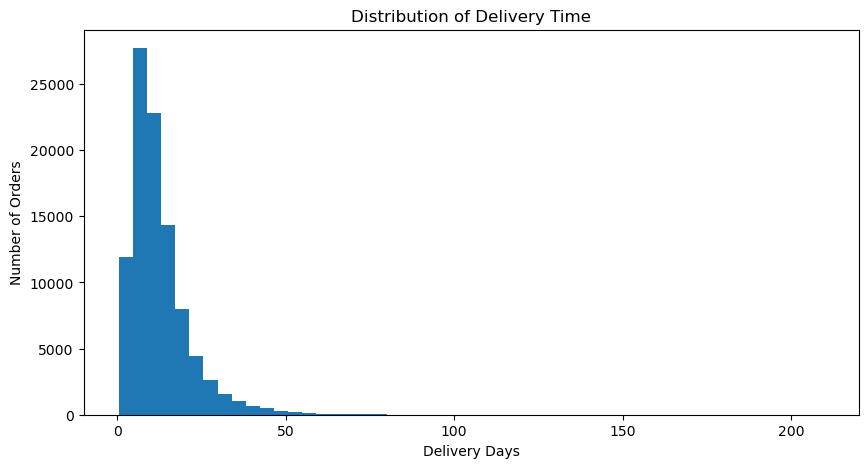

In [55]:
delivered_orders["delivery_days"].plot(kind="hist",bins=50,figsize=(10, 5))

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

In [56]:
# Calculating late deliveries
delivered_orders["is_late"] = (
    delivered_orders["order_delivered_customer_date"] > delivered_orders["order_estimated_delivery_date"]
)

In [58]:
delivered_orders["is_late"].value_counts()

is_late
False    88652
True      7826
Name: count, dtype: int64

In [60]:
late_delivery_rate = (delivered_orders["is_late"].mean() * 100)
print(f"Late delivery rate: {late_delivery_rate:.2f}%")

Late delivery rate: 8.11%


In [59]:
delivered_orders["is_late"].mean()

np.float64(0.08111693857667032)

In [61]:
print("Customer records:", total_customer_records)
print("Unique customers:", unique_customers)
print("Repeat customers:", repeat_customers)
print(f"Repeat customer rate: {repeat_customer_rate:.2f}%")

Customer records: 99441
Unique customers: 96096
Repeat customers: 2997
Repeat customer rate: 3.12%


In [62]:
print("Invalid delivery dates:", len(invalid_delivery_dates))
print("Invalid estimated dates:", len(invalid_estimated_dates))
print(f"Late delivery rate: {late_delivery_rate:.2f}%")

Invalid delivery dates: 0
Invalid estimated dates: 0
Late delivery rate: 8.11%


### Findings

- Customer retention is low - 99,441 customer records, 96,096 unique customers, 2,997 repeat customers, 3.12% repeat customer rate. This suggests that the company contains a large proportion of one-time purchasers.
- Late delivery rate is 8.11% - About 8.11% of delivered orders were delivered after the estimated delivery date.
